#1. Data Collection

In [5]:
import pandas as pd
import numpy as np

health = pd.read_csv("Health_Data.csv")
walkability = pd.read_csv("Walkability_Data.csv")
census = pd.read_json("Census_Data.json")

census.columns = census.iloc[0]
census = census[1:].reset_index(drop=True)
for c in census.columns:
    census[c] = pd.to_numeric(census[c], errors='coerce')

census['countyfips'] = (census['state'] * 1000 + census['county']).astype('Int64')
census['Median_HH_Income'] = census['B19013_001E']

male_65_cols = ['B01001_020E','B01001_021E','B01001_022E',
                'B01001_023E','B01001_024E','B01001_025E']
female_65_cols = ['B01001_044E','B01001_045E','B01001_046E',
                  'B01001_047E','B01001_048E','B01001_049E']

census['Pct_65_Plus'] = (
    census[male_65_cols].sum(axis=1) + census[female_65_cols].sum(axis=1)
) / census['B01001_001E'] * 100

census = census[['countyfips', 'Median_HH_Income', 'Pct_65_Plus']].dropna(subset=['countyfips'])
census['countyfips'] = census['countyfips'].astype(int)

walkability = walkability.dropna(subset=['STATEFP', 'COUNTYFP'])
walkability['countyfips'] = (
    walkability['STATEFP'].astype(int).astype(str).str.zfill(2) +
    walkability['COUNTYFP'].astype(int).astype(str).str.zfill(3)
).astype(int)
walkability['_w'] = walkability['TotPop'].clip(lower=1)
walkability['_w_walk'] = walkability['NatWalkInd'].fillna(0) * walkability['_w']
county_walk = walkability.groupby('countyfips').agg(
    _w_walk=('_w_walk', 'sum'), _w_sum=('_w', 'sum')
).reset_index()
county_walk['Walkability'] = county_walk['_w_walk'] / county_walk['_w_sum']
county_walk = county_walk[['countyfips', 'Walkability']]

cvd = health[health['measure'] == 'Coronary heart disease among adults'][['countyfips', 'stateabbr', 'countyname', 'data_value']].copy()
cvd['countyfips'] = cvd['countyfips'].astype(int)

df = (
    cvd.merge(county_walk, on='countyfips', how='inner')
       .merge(census, on='countyfips', how='left')
       .replace(-99999.0, np.nan)
       .groupby(['countyfips', 'stateabbr', 'countyname'])
       .agg(
           CVD_Prevalence=('data_value', 'mean'),
           Walkability=('Walkability', 'first'),
           Median_HH_Income=('Median_HH_Income', 'first'),
           Pct_65_Plus=('Pct_65_Plus', 'first')
       )
       .reset_index()
       .rename(columns={'countyfips': 'County_FIPS', 'stateabbr': 'State', 'countyname': 'County'})
       .dropna()
)

print(f"Shape: {df.shape}")
print(df.head(10))

Shape: (2945, 7)
   County_FIPS State    County  CVD_Prevalence  Walkability  Median_HH_Income  \
0         1001    AL   Autauga        6.747059     5.483179             69841   
1         1003    AL   Baldwin        7.669767     6.812502             75019   
2         1005    AL   Barbour        9.522222     5.156175             44290   
3         1007    AL      Bibb        8.275000     5.241296             51215   
4         1009    AL    Blount        8.025000     4.674447             61096   
5         1011    AL   Bullock       10.475000     4.500982             36723   
6         1013    AL    Butler        9.144444     5.482813             44881   
7         1015    AL   Calhoun        8.085714     5.730447             55826   
8         1017    AL  Chambers        8.677778     5.250828             49295   
9         1019    AL  Cherokee        9.562500     4.323618             50769   

   Pct_65_Plus  
0    15.980433  
1    21.390735  
2    19.715636  
3    16.955580  
4    1

##2. Data Cleaning

In [6]:
print("=== BEFORE CLEANING ===")
print(df.describe())
print(f"\nShape: {df.shape}")

for col in ['CVD_Prevalence', 'Walkability', 'Median_HH_Income', 'Pct_65_Plus']:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  NaN: {df[col].isna().sum()}")
    print(f"  Negative: {(df[col] < 0).sum()}")
    print(f"  Zero: {(df[col] == 0).sum()}")

=== BEFORE CLEANING ===
        County_FIPS  CVD_Prevalence  Walkability  Median_HH_Income  \
count   2945.000000     2945.000000  2945.000000      2.945000e+03   
mean   30556.845840        7.891084     6.519090     -3.864718e+05   
std    15395.835404        1.482759     1.909137      1.737204e+07   
min     1001.000000        2.840000     2.860761     -6.666667e+08   
25%    18097.000000        6.957143     5.339030      5.517400e+04   
50%    30007.000000        7.975000     6.114923      6.395500e+04   
75%    46087.000000        8.880000     7.040413      7.385500e+04   
max    56045.000000       13.925000    15.997713      1.787070e+05   

       Pct_65_Plus  
count  2945.000000  
mean     20.074410  
std       5.004559  
min       3.322078  
25%      16.841534  
50%      19.693816  
75%      22.693920  
max      57.776146  

Shape: (2945, 7)

CVD_Prevalence:
  Min: 2.84
  Max: 13.925
  NaN: 0
  Negative: 0
  Zero: 0

Walkability:
  Min: 2.860760760875075
  Max: 15.9977133233020

In [7]:
df = df[
    (df['Median_HH_Income'] > 0)
].copy()

##3. Data Visualization

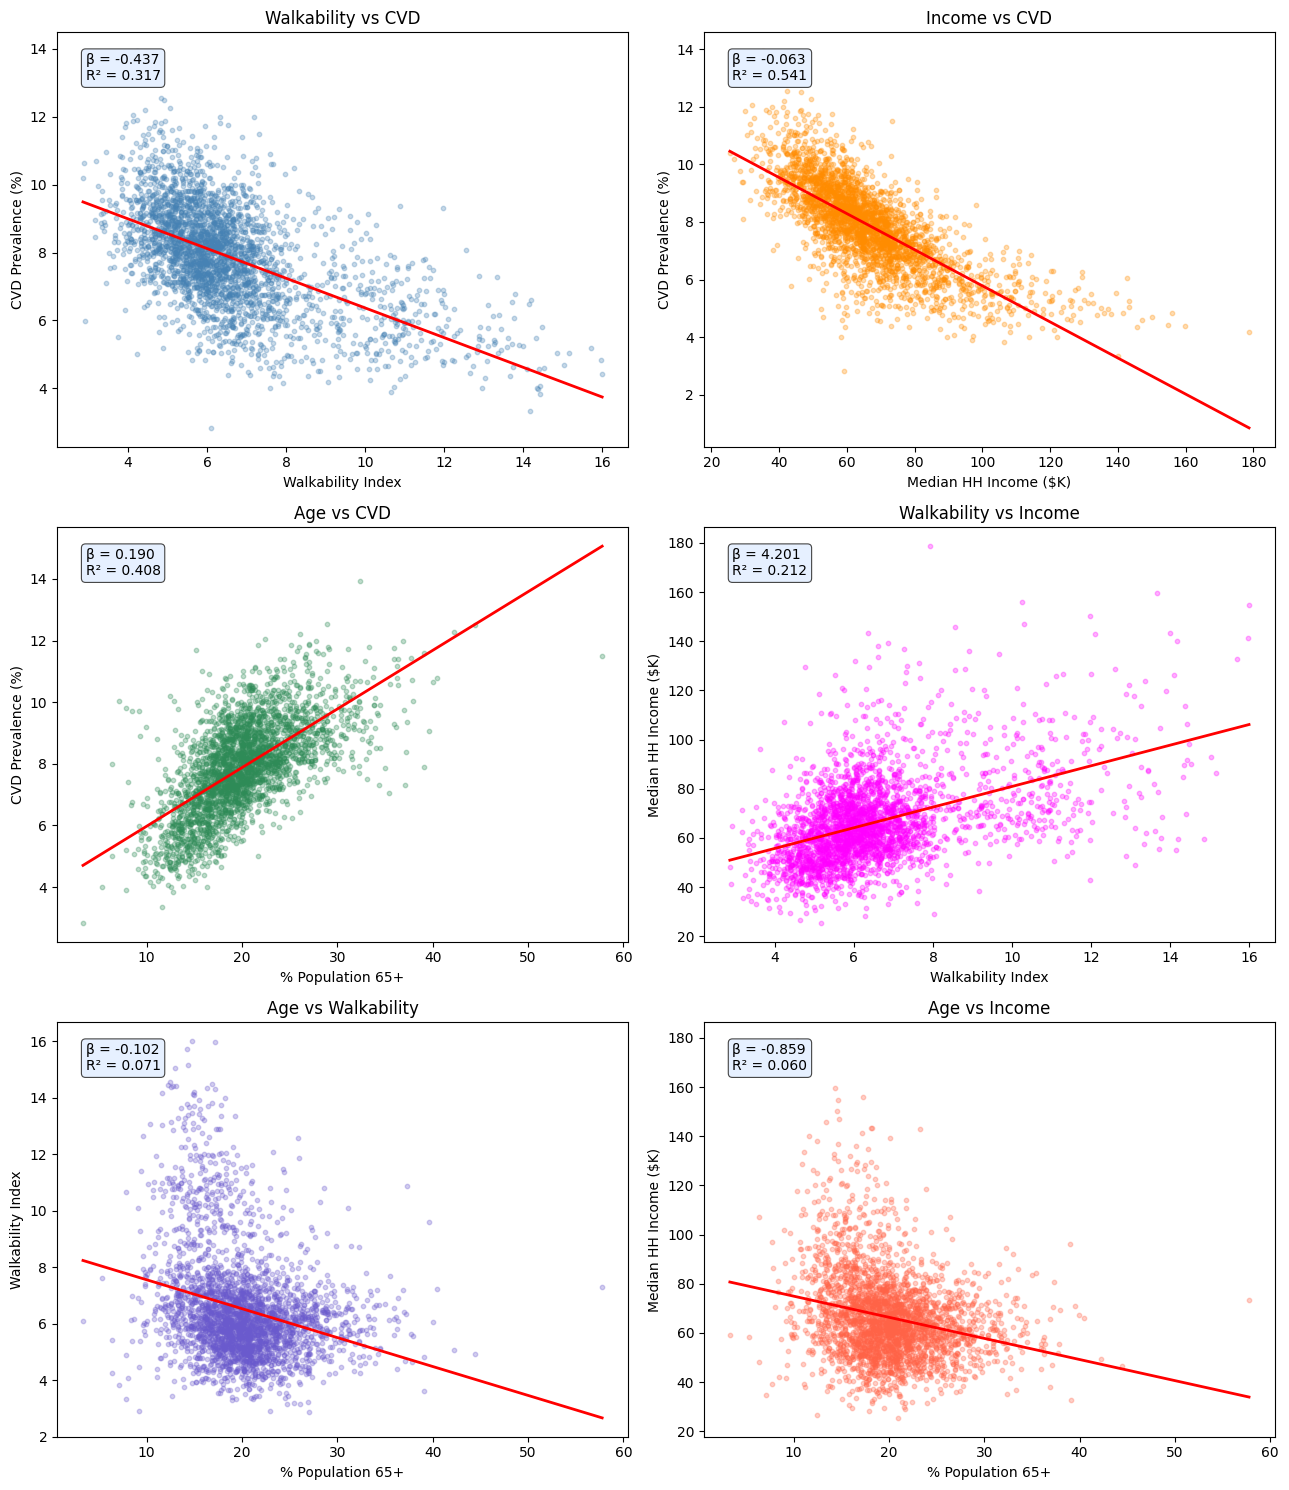

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(13, 15))

box_style = dict(boxstyle='round', facecolor='#e6f0ff', edgecolor='#444444', linewidth=0.8)

pairs = [
    ('Walkability', 'CVD_Prevalence', 'Walkability Index', 'CVD Prevalence (%)', 'Walkability vs CVD', 'steelblue'),
    ('Median_HH_Income', 'CVD_Prevalence', 'Median HH Income ($K)', 'CVD Prevalence (%)', 'Income vs CVD', 'darkorange'),
    ('Pct_65_Plus', 'CVD_Prevalence', '% Population 65+', 'CVD Prevalence (%)', 'Age vs CVD', 'seagreen'),
    ('Walkability', 'Median_HH_Income', 'Walkability Index', 'Median HH Income ($K)', 'Walkability vs Income', 'magenta'),
    ('Pct_65_Plus', 'Walkability', '% Population 65+', 'Walkability Index', 'Age vs Walkability', 'slateblue'),
    ('Pct_65_Plus', 'Median_HH_Income', '% Population 65+', 'Median HH Income ($K)', 'Age vs Income', 'tomato'),
]

for i, (xcol, ycol, xlab, ylab, title, color) in enumerate(pairs):
    ax = axes[i // 2, i % 2]

    xdata = df[xcol] / 1000 if 'Income' in xcol else df[xcol]
    ydata = df[ycol] / 1000 if 'Income' in ycol else df[ycol]

    ax.scatter(xdata, ydata, alpha=0.3, s=10, color=color)
    z = np.polyfit(xdata, ydata, 1)
    ax.plot(np.sort(xdata), np.polyval(z, np.sort(xdata)), color='red', linewidth=2)
    r2 = np.corrcoef(xdata, ydata)[0, 1] ** 2
    ax.text(0.05, 0.95, f"β = {z[0]:.3f}\nR² = {r2:.3f}",
            transform=ax.transAxes, va='top', fontsize=10, color='black', bbox=box_style)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)

plt.tight_layout()
plt.show()

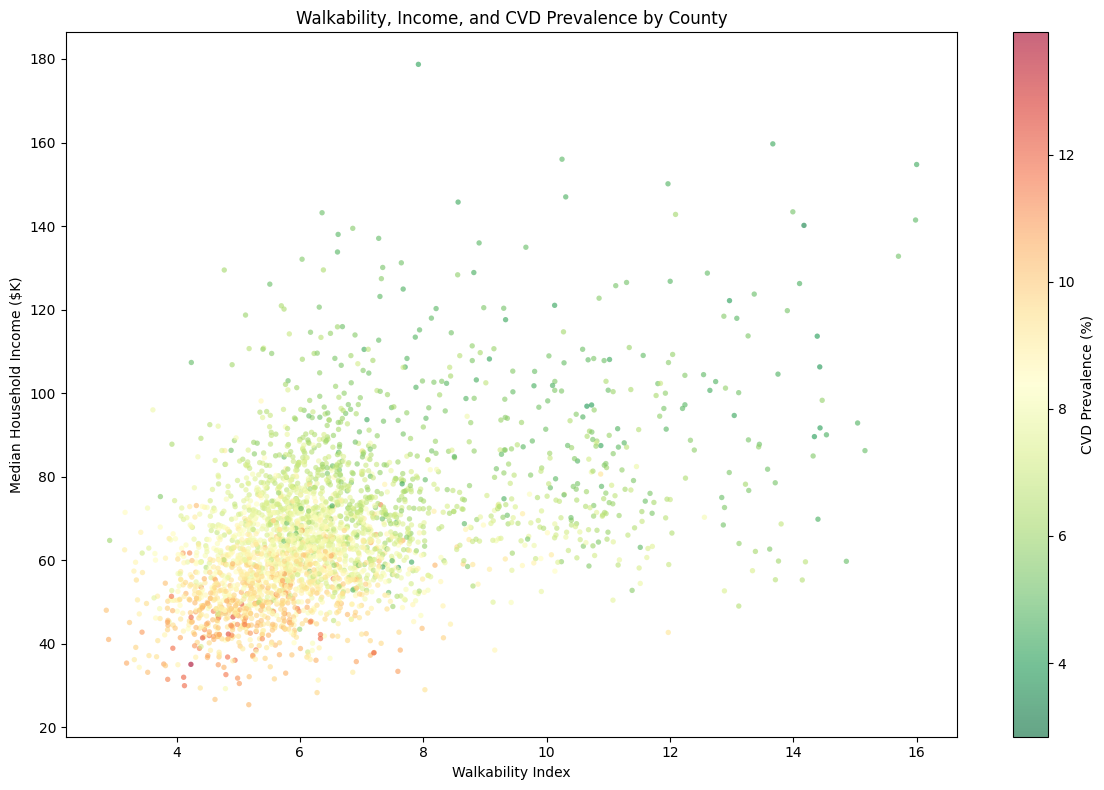

In [9]:
plot_df = df[(df['Median_HH_Income'] > 20000) & (df['Median_HH_Income'] < 200000)].copy()

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    plot_df['Walkability'],
    plot_df['Median_HH_Income'] / 1000,
    c=plot_df['CVD_Prevalence'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=15,
    edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('CVD Prevalence (%)')

ax.set_xlabel('Walkability Index')
ax.set_ylabel('Median Household Income ($K)')
ax.set_title('Walkability, Income, and CVD Prevalence by County')

plt.tight_layout()
plt.show()

It's important to note that walkability, age, and income are all correlated with CVD prevalence. A higher walkability score or median income, and a lower aged population are correlated with lower CVD rates.

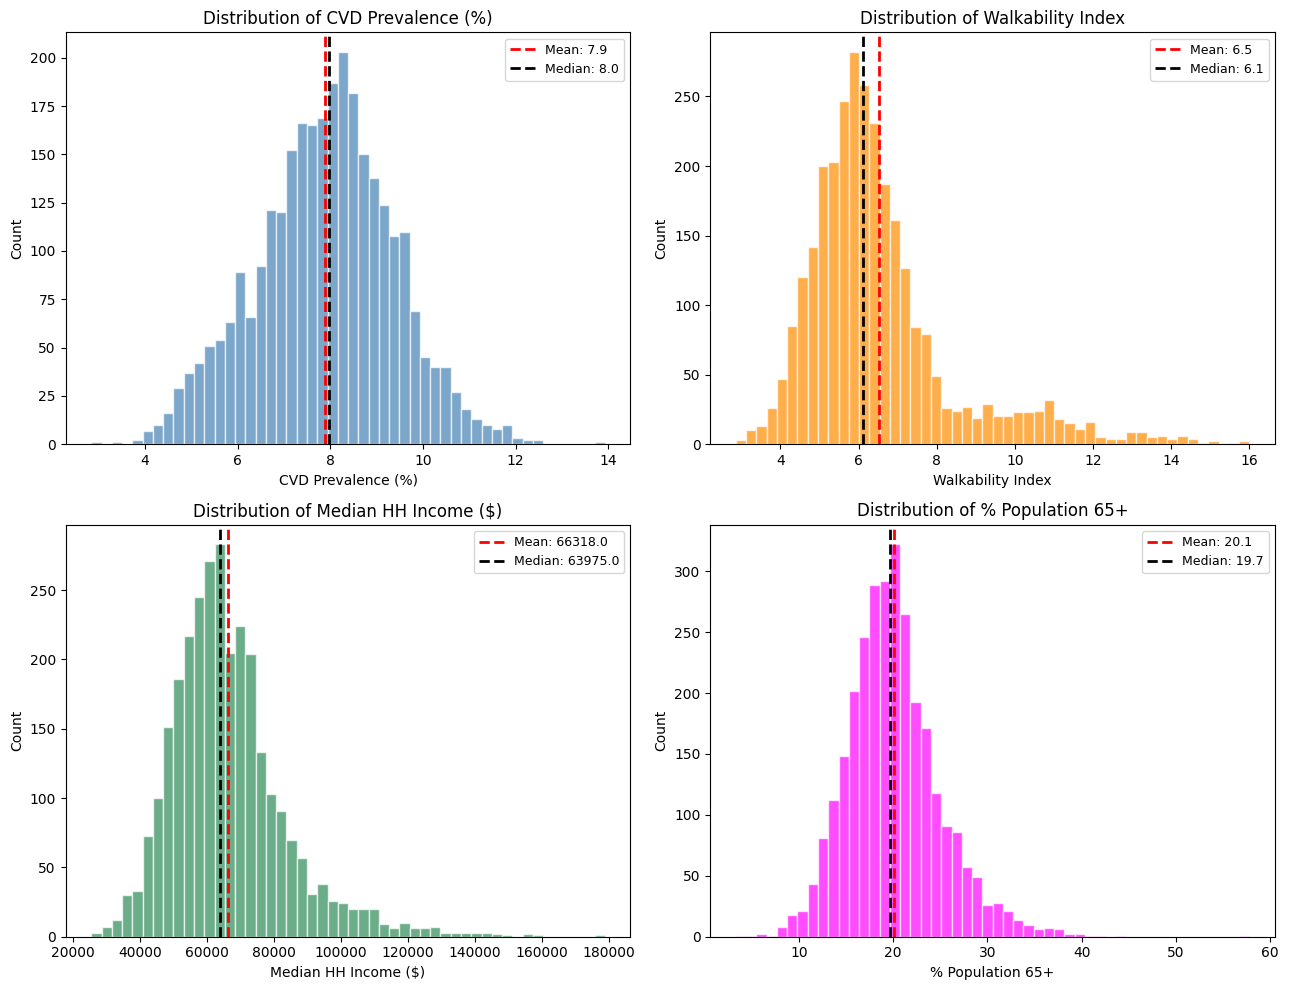

=== 10 MOST WALKABLE COUNTIES ===
              County State  Walkability  CVD_Prevalence  Median_HH_Income
        Falls Church    VA    15.997713        4.433333            154734
       San Francisco    CA    15.980290        4.836100            141446
             Fairfax    VA    15.702863        5.200000            132774
           Multnomah    OR    15.160062        5.029949             86247
             Suffolk    MA    15.040694        4.689189             92859
        Harrisonburg    VA    14.858469        5.036364             59752
              Hudson    NJ    14.535586        4.591209             90032
            Richmond    NY    14.466467        5.813333             98290
              Denver    CO    14.431755        4.084091             91681
District of Columbia    DC    14.427022        3.842718            106287

=== 10 LEAST WALKABLE COUNTIES ===
     County State  Walkability  CVD_Prevalence  Median_HH_Income
 Taliaferro    GA     2.860761       10.200000     

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
cols = ['CVD_Prevalence', 'Walkability', 'Median_HH_Income', 'Pct_65_Plus']
colors = ['steelblue', 'darkorange', 'seagreen', 'magenta']
titles = ['CVD Prevalence (%)', 'Walkability Index', 'Median HH Income ($)', '% Population 65+']

for i, (col, color, title) in enumerate(zip(cols, colors, titles)):
    ax = axes[i // 2, i % 2]
    ax.hist(df[col], bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    ax.legend(fontsize=9)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {title}')

plt.tight_layout()
plt.show()

print("=== 10 MOST WALKABLE COUNTIES ===")
print(df.nlargest(10, 'Walkability')[['County', 'State', 'Walkability', 'CVD_Prevalence', 'Median_HH_Income']].to_string(index=False))

print("\n=== 10 LEAST WALKABLE COUNTIES ===")
print(df.nsmallest(10, 'Walkability')[['County', 'State', 'Walkability', 'CVD_Prevalence', 'Median_HH_Income']].to_string(index=False))

state_avg = (
    df.groupby('State')
    .agg(
        Avg_CVD=('CVD_Prevalence', 'mean'),
        Avg_Walk=('Walkability', 'mean'),
        Avg_Income=('Median_HH_Income', 'mean'),
        Counties=('County_FIPS', 'count'),
    )
    .sort_values('Avg_CVD', ascending=False)
)
print("\n=== STATE AVERAGES (sorted by CVD) ===")
print(state_avg.head(15).to_string())

import plotly.express as px
import numpy as np

state_avg = df.groupby('State').agg(
    Avg_Walkability=('Walkability', 'mean'),
).reset_index()

bins = state_avg['Avg_Walkability'].quantile(np.linspace(0, 1, 11)).values

colors = [
    '#d73027', '#f46d43', '#fdae61', '#fee08b', '#ffffbf',
    '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850', '#006837'
]

colorscale = []
for i in range(10):
    frac_start = (bins[i] - bins[0]) / (bins[-1] - bins[0])
    frac_end = (bins[i+1] - bins[0]) / (bins[-1] - bins[0])
    colorscale.append([frac_start, colors[i]])
    colorscale.append([frac_end, colors[i]])

fig = px.choropleth(
    state_avg,
    locations='State',
    locationmode='USA-states',
    color='Avg_Walkability',
    scope='usa',
    labels={'Avg_Walkability': 'Walkability Index'},
    range_color=[bins[0], bins[-1]],
)

fig.update_traces(
    marker_line_color='white',
    marker_line_width=1.5,
)

fig.update_coloraxes(
    colorscale=colorscale,
    colorbar=dict(
        title=dict(text='Walkability<br>Index', font=dict(size=14)),
        len=0.75,
        thickness=15,
        outlinewidth=0,
    )
)

fig.update_layout(
    title=dict(
        text='Average Walkability Index by State',
        font=dict(size=22, family='Arial'),
        x=0.5,
        xanchor='center',
    ),
    geo=dict(
        lakecolor='#eaf2f8',
        bgcolor='white',
        landcolor='#f9f9f9',
        showlakes=True,
        showframe=False,
        projection_type='albers usa',
    ),
    width=1000,
    height=600,
    margin=dict(l=20, r=20, t=60, b=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    annotations=[
        dict(
            text='Source: EPA Smart Location Database | County-level population-weighted averages',
            xref='paper', yref='paper',
            x=0.5, y=-0.02,
            showarrow=False,
            font=dict(size=10, color='grey'),
        )
    ]
)

fig.show()

Looking at the distributions, CVD prevalence is fairly evenly spread across counties with most falling around 8%, while walkability and income both skew right since most counties are suburban or rural with a smaller number of wealthier, more walkable urban areas pulling the averages up. This skew in income is part of why we log-transform it later in the regression. The share of residents 65 and older is more evenly distributed, hovering around 20% for most counties but with enough variation to make it a useful control for age-related confounding in our models.

##4. Regression
###4.1 Raw Regression

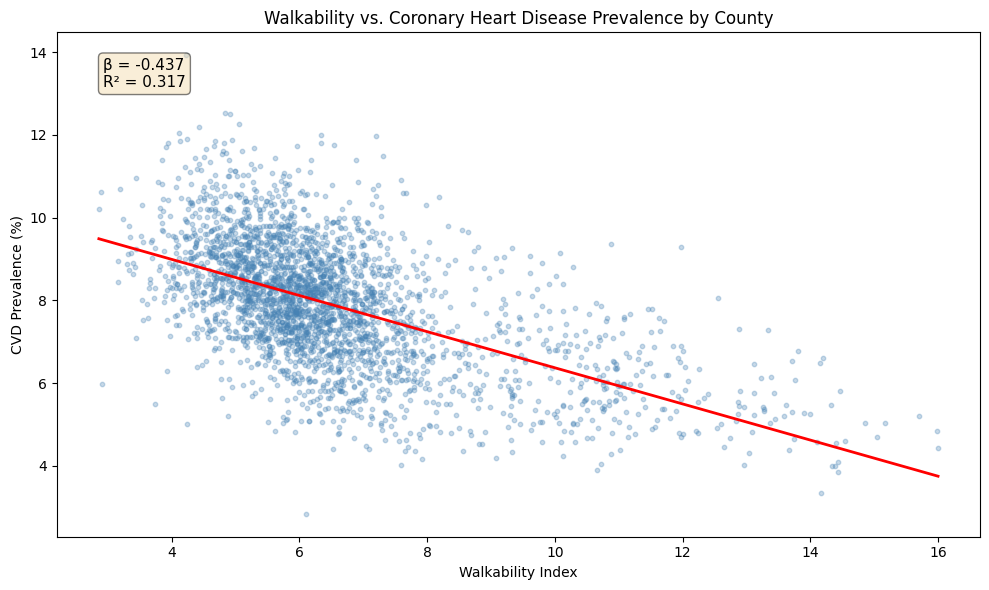

In [11]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

X = sm.add_constant(df['Walkability'])
y = df['CVD_Prevalence']
model = sm.OLS(y, X).fit()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Walkability'], df['CVD_Prevalence'], alpha=0.3, s=10, color='steelblue')
ax.plot(df['Walkability'].sort_values(), model.predict(sm.add_constant(df['Walkability'].sort_values())),
        color='red', linewidth=2)

ax.set_xlabel('Walkability Index')
ax.set_ylabel('CVD Prevalence (%)')
ax.set_title('Walkability vs. Coronary Heart Disease Prevalence by County')
ax.text(0.05, 0.95, f"β = {model.params['Walkability']:.3f}\nR² = {model.rsquared:.3f}",
        transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

###4.2 Controls

In [18]:
import statsmodels.api as sm

df = df[df['Median_HH_Income'] > 0].copy()
df['Log_Income'] = np.log(df['Median_HH_Income'])

y = df['CVD_Prevalence']

m1 = sm.OLS(y, sm.add_constant(df[['Walkability']])).fit()

m2 = sm.OLS(y, sm.add_constant(df[['Walkability', 'Log_Income']])).fit(cov_type='HC1')

m3 = sm.OLS(y, sm.add_constant(df[['Walkability', 'Log_Income', 'Pct_65_Plus']])).fit(cov_type='HC1')

print(f"{'Model':<30} {'Walk β':>10} {'R²':>10}")
print("-" * 53)
print(f"{'1: Raw':<30} {m1.params['Walkability']:>10.4f} {m1.rsquared:>10.3f}")
print(f"{'2: + Log Income':<30} {m2.params['Walkability']:>10.4f} {m2.rsquared:>10.3f}")
print(f"{'3: + Log Income + Age':<30} {m3.params['Walkability']:>10.4f} {m3.rsquared:>10.3f}")

print(f"\nDecomposition:")
print(f"Income explains:    {(1 - m2.params['Walkability']/m1.params['Walkability'])*100:.1f}%")
print(f"Age explains:       {(1 - m3.params['Walkability']/m2.params['Walkability'])*100:.1f}% beyond income")
print(f"Total confounding:  {(1 - m3.params['Walkability']/m1.params['Walkability'])*100:.1f}%")
print(f"Independent effect: {100 - (1 - m3.params['Walkability']/m1.params['Walkability'])*100:.1f}%")


Model                              Walk β         R²
-----------------------------------------------------
1: Raw                            -0.4370      0.317
2: + Log Income                   -0.2186      0.626
3: + Log Income + Age             -0.1445      0.821

Decomposition:
Income explains:    50.0%
Age explains:       33.9% beyond income
Total confounding:  66.9%
Independent effect: 33.1%
